# 02. Практика графиков (matplotlib + seaborn)

Этот ноутбук — **песочница** для тренировки построения графиков. Настоящий анализ данных (EDA) будет позже, в отдельном ноутбуке.

## Содержание

1. Импорты и настройка темы
2. Общие параметры seaborn-графиков
3. График 1: Гистограмма `alcohol` (`histplot`)
4. График 2: Boxplot `alcohol` (`boxplot`)
5. График 3: Countplot `quality` (`countplot`)
6. Цепочка методов `value_counts`


## 1. Импорты и настройка темы

Три библиотеки, которые нам нужны:

- **`pandas as pd`** — работа с таблицами: загрузка CSV, фильтрация, группировка, подсчёты.
- **`matplotlib.pyplot as plt`** — базовая библиотека графиков. Рисует всё «под капотом», даже когда мы вызываем seaborn. Иногда нужна для тонкой настройки (подписи, размеры).
- **`seaborn as sns`** — надстройка над matplotlib. Короче пишется, красивее выглядит. **Основная библиотека для графиков в этом ноутбуке.**

### Настройка темы

```python
sns.set_theme(style="darkgrid")
```

`set_theme()` устанавливает **оформление для всех графиков ниже**. Доступные стили:

- `"white"` — белый фон, без сетки
- `"dark"` — тёмный фон, без сетки
- `"whitegrid"` — белый фон + сетка
- `"darkgrid"` — тёмный фон + сетка
- `"ticks"` — белый фон + засечки (как в научных статьях)

Мы используем `"darkgrid"` — тёмный фон подходит к теме VS Code, сетка помогает читать значения.

## 2. Общие параметры seaborn-графиков

У всех графиков seaborn есть **одинаковые базовые параметры**. Их не нужно разбирать в каждом графике заново — они везде означают одно и то же.

- **`sns.имя_функции(...)`** — обращение к библиотеке seaborn. `sns` — сокращение из `import seaborn as sns`.
- **`data=df`** — из какой **таблицы** брать данные. `df` — наш DataFrame.
- **`x="имя_столбца"`** — что отложить по оси X. Имя столбца в кавычках — это **строка**, а не переменная.
- **`y="имя_столбца"`** — что отложить по оси Y.

Дальше у **каждого графика** есть свои специфичные параметры (например, `bins` у гистограммы) — их разбираем в расшифровке конкретного графика.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
df = pd.read_csv("../data/raw/wine_quality_merged.csv")
df.shape


(6497, 13)

## 3. График 1: Гистограмма `alcohol`

### Теория

**Гистограмма** — график, который показывает, **как часто** встречаются разные значения признака. Используется для **непрерывных** чисел (как `alcohol`).

**Как читать:**
- **Ось X** — значение признака.
- **Ось Y** — сколько раз это значение встретилось.
- **Чем выше столбик** — тем чаще это значение.
- **Форма распределения** — где основная масса значений, есть ли второй «горб», куда уходят хвосты.

**Зачем:** быстро понять «как выглядят» данные — симметрично ли распределение, где центр, есть ли аномалии.

<Axes: xlabel='alcohol', ylabel='Count'>

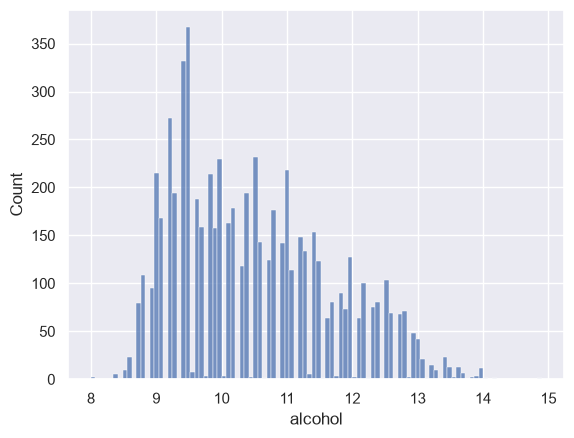

In [28]:
sns.histplot(data=df, x="alcohol", bins=100)

## 4. График 2: Boxplot `alcohol`

### Теория

**Boxplot (ящик с усами)** — график, который показывает **разброс** значений признака: где середина, где основная масса, есть ли выбросы. Это «сжатая» картинка всего распределения.

Если выстроить все значения в ряд по возрастанию, boxplot показывает **5 ключевых точек**:

- **Медиана (линия внутри ящика)** — делит данные пополам: 50% ниже, 50% выше. Это **середина**, а не среднее арифметическое.
- **Ящик** — от **Q1 (25-й процентиль)** до **Q3 (75-й процентиль)**. Внутри — «основная масса» данных (средние 50%).
- **Усы** (линии из ящика) — границы «нормальных» значений.
- **Точки за усами (○)** — **выбросы**. Статистически нетипичные значения. Это **не ошибки**, просто редкие.

**Как читать:**
- **Широкий ящик** — большой разброс «средней» части данных. Узкий — значения кучно у медианы.
- **Длинные усы** — большой разброс в крайних частях.
- **Медиана не по центру ящика** — распределение **скошено** (длинный хвост в одну сторону).
- **Много точек за усами** — много нетипичных значений.

**Как определяются выбросы:** считается `IQR = Q3 − Q1` (размер ящика). Всё, что **выше** `Q3 + 1.5 × IQR` — выброс сверху. Всё, что **ниже** `Q1 − 1.5 × IQR` — выброс снизу. Это правило seaborn использует по умолчанию.

**Зачем:** быстро понять разброс, найти выбросы, сравнить группы.

<Axes: xlabel='alcohol'>

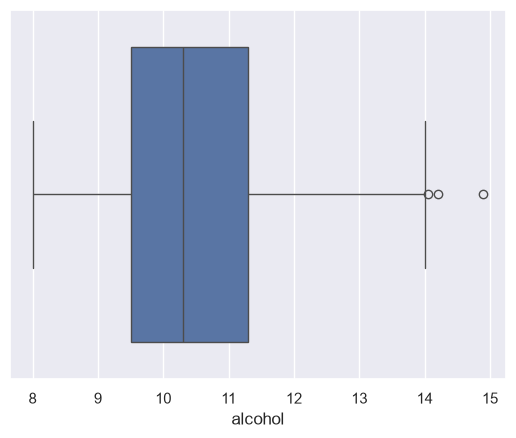

In [24]:
sns.boxplot(data=df, x="alcohol")

<Axes: ylabel='alcohol'>

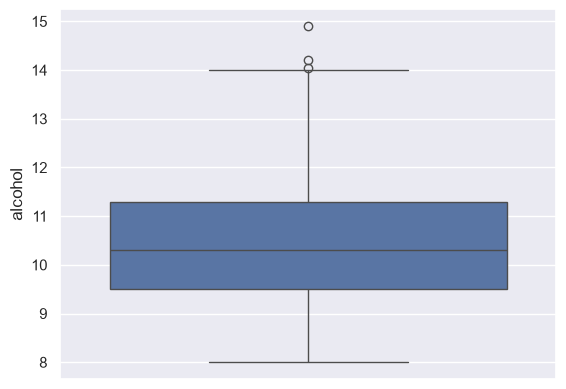

In [25]:
sns.boxplot(data=df, y="alcohol")

### Расшифровка команды `sns.boxplot(...)`

```python
sns.boxplot(data=df, x="alcohol")
```

Из **общих параметров** (раздел 3) здесь используются:
- `data=df` — таблица с данными.
- `x="alcohol"` — что рисовать.

**Специфика boxplot:** параметр `x` делает boxplot **горизонтальным** (значения по оси X, ящик вытянут горизонтально). Если хочешь **вертикальный** — используй `y="alcohol"` вместо `x`.

## 5. График 3: Countplot `quality`

### Теория

**Countplot** — столбчатая диаграмма, которая **считает**, сколько раз встречается каждое значение признака. Это гистограмма для **дискретных** значений (когда значения — отдельные категории или целые числа, а не непрерывная шкала).

**Чем отличается от histplot:**
- **`histplot`** — для **непрерывных** значений (алкоголь: 9.1, 9.2, 9.3...). **Разбивает** диапазон на интервалы.
- **`countplot`** — для **дискретных** (quality: 3, 4, 5, 6, 7, 8, 9). **Не разбивает** — для каждого уникального значения один столбик.

Проще: если значения — «какая величина на шкале» → `histplot`. Если «сколько штук» или «какая категория» → `countplot`.

**Как читать:**
- **Ось X** — уникальные значения признака.
- **Ось Y** — сколько раз каждое значение встретилось.
- **Высота столбика** — частота.

**Зачем:** увидеть, **сбалансированы ли классы**. Если один столбик сильно выше — это **дисбаланс классов**, и модель будет «лениться» предсказывать редкие классы.

**Почему это важно для `quality`:** `quality` — наш **целевой признак** (то, что модель будет предсказывать). Если 90% вин имеют оценку 6, а оценка 3 — у 3 вин, модель, которая **всегда** говорит «6», будет права в 90% случаев. Это проблема — точность высокая, а пользы мало.

<Axes: xlabel='quality', ylabel='count'>

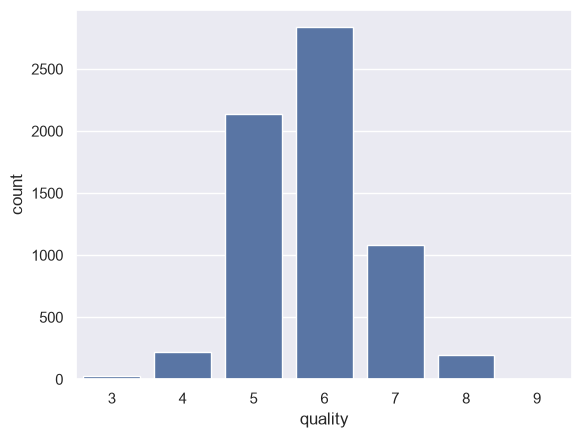

In [26]:
sns.countplot(data=df, x="quality")

In [27]:
df["quality"].value_counts().sort_index()

quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

### Расшифровка команды `df["quality"].value_counts().sort_index()`

Это **цепочка методов** — каждое звено берёт результат предыдущего и делает с ним что-то своё. Читается слева направо.

### Разбор по шагам

**1. `df["quality"]`**

Достаём столбец `quality` из таблицы. Квадратные скобки `[...]` + имя столбца в кавычках (это строка, а не переменная). Результат — отдельный столбец (в pandas называется **Series**).

**2. `.value_counts()`**

Считаем, сколько раз встречается **каждое уникальное значение**. Возвращает табличку вида «значение → сколько раз». По умолчанию сортирует **по убыванию частоты** (самое частое сверху).

**3. `.sort_index()`**

Сортируем результат **по индексу** (по значениям `quality`: 3, 4, 5, 6, ...), а не по частоте. Так удобнее — оценки идут по порядку, и сразу видно форму распределения.

**4. `()` в конце**

Пустые скобки — потому что `value_counts` и `sort_index` это **методы** (функции), а не свойства. Без скобок они не выполнятся. Сравни: `df.shape` — свойство (без скобок), `df.value_counts()` — метод (нужны скобки).

### Итог

«Возьми столбец `quality`, посчитай, сколько раз встречается каждая оценка, отсортируй результат по возрастанию оценки».

### Что такое цепочка методов (method chaining)

Каждый метод возвращает **новый объект**, и к нему можно **сразу же** применить следующий метод. Это стандартный стиль в pandas — одна строка делает несколько последовательных действий.

**Примеры других цепочек:**

```python
df["alcohol"].describe()   # взять столбец → посчитать статистику
df["alcohol"].mean()       # взять столбец → посчитать среднее
df["quality"].max()        # взять столбец → найти максимум
```

**Шаблон:** `df["имя_столбца"].метод()` — базовая конструкция, которую ты будешь использовать постоянно.

### Что мы видим на нашем графике

Точные числа (из `df["quality"].value_counts().sort_index()`):

| Оценка | Количество вин |
|--------|----------------|
| 3      | 30             |
| 4      | 216            |
| 5      | 2138           |
| 6      | 2836           |
| 7      | 1079           |
| 8      | 193            |
| 9      | 5              |

**Что видно:**
- **Оценка 6 — самая частая** (2836 вин, ~44%).
- **Оценка 5 — вторая** (2138 вин, ~33%).
- **Оценка 7 — третья** (1079 вин, ~17%).
- **Оценки 4 и 8 — редкие** (~200 вин каждая).
- **Оценка 3 — почти отсутствует** (30 вин).
- **Оценка 9 — единичные случаи** (5 вин).

### Форма распределения

Это **не «колокол»**, а одна высокая гора с центром на 6, небольшим «плечом» на 5 и **быстро убывающими хвостами** в обе стороны.

### Главный вывод: сильный дисбаланс классов

- **5 и 6 вместе** — это **~77% всех вин**.
- **3, 4, 8, 9** — редкие классы, вместе меньше 10%.

**Что это значит для модели:**
Если модель будет **всегда** предсказывать 6 — она угадает примерно **44%** случаев. Если «6 или 5» — уже ~77%. Это **обманчиво высокая точность**, за которой скрывается неумение предсказывать редкие оценки.


## 6. Общие выводы по визуализации

Что мы узнали о датасете через графики:

### 1. `alcohol` — распределение скошено вправо
- Медиана ~10.3, основная масса — от 9.5 до 11.3.
- Есть редкие выбросы (>14.0) — очень крепкие вина.
- Минимум 8.0, максимум 14.9.

### 2. `quality` — сильный дисбаланс классов
- 77% вин имеют оценку 5 или 6.
- Оценки 3, 4, 8, 9 — редкие.
- **Проблема для модели:** она будет «лениться» предсказывать редкие оценки.

### 3. Что дальше
- Построить графики для **других признаков** (fixed acidity, volatile acidity, residual sugar, pH и т.д.).
- Сравнить **red vs white** — отличаются ли распределения признаков у красного и белого вина.
- Построить **heatmap корреляций** — какие признаки связаны друг с другом.
- Перейти к **предобработке данных** (масштабирование, train/test split) и **моделям**.

### 4. Полезные приёмы, которые мы освоили
- `sns.histplot(data=df, x="...", bins=N)` — гистограмма.
- `sns.boxplot(data=df, x="...")` — boxplot.
- `sns.countplot(data=df, x="...")` — счётный график.
- `df["column"].value_counts().sort_index()` — частоты по значениям.
- `sns.set_theme(style="...")` — настройка стиля.